# **02 — Modeling**

## 1. Setup

In [1]:
REPO_URL = "https://github.com/DhairyaDave08/Sentiment-Analysis"
REPO_DIR = "sentiment-analysis"

import os, sys

if REPO_URL and not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

sys.path.append(os.path.abspath(REPO_DIR))

from src.feature.vectorize import fit_vectorizer, transform_texts, save_vectorizer
from src.model.train import train_model, save_model
from src.model.evaluate import evaluate_model, print_results

Cloning into 'sentiment-analysis'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 48 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 70.61 KiB | 6.42 MiB/s, done.
Resolving deltas: 100% (14/14), done.


## 2. Load processed data

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

from src.preprocessing.clean_text import clean_text
from src.preprocessing.tokenize import process

COLUMN_NAMES = ["target", "ids", "date", "flag", "user", "text"]

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kazanova/sentiment140",
    "training.1600000.processed.noemoticon.csv",
    pandas_kwargs={
        "encoding": "latin-1",
        "header": None,
        "names": COLUMN_NAMES,
    },
)

df["cleaned"] = df["text"].apply(clean_text)
df["processed"] = df["cleaned"].apply(process)

processed_df = df[["target", "processed"]].copy()

os.makedirs("data/processed", exist_ok=True)
processed_df.to_csv("data/processed/processed_tweets.csv", index=False)

print(f"Generated {len(processed_df)} rows")
processed_df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipykernel_963/3181846669.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sentiment140' dataset.
Generated 1600000 rows


,target,processed
0,0,awww bummer shoulda got david carr third day
1,0,upset updat facebook text might cri result sch...
2,0,dive mani time ball manag save rest go bound
3,0,whole bodi feel itchi like fire
4,0,behav mad see


## 3. Train/test split

In [3]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    processed_df["processed"],
    processed_df["target"],
    test_size=0.2,
    random_state=42,
    stratify=processed_df["target"],
)

print(f"Train: {len(X_train_text)}, Test: {len(X_test_text)}")

Train: 1280000, Test: 320000


## 4. TF-IDF vectorization

In [4]:
vectorizer = fit_vectorizer(X_train_text, max_features=5000)

X_train = transform_texts(vectorizer, X_train_text)
X_test = transform_texts(vectorizer, X_test_text)

print(X_train.shape, X_test.shape)

(1280000, 5000) (320000, 5000)


## 5. Train and compare models

In [5]:
model_names = ["logistic_regression", "naive_bayes", "svm"]
results_by_model = {}

for name in model_names:
    print(f"\n=== {name} ===")
    model = train_model(X_train, y_train, model_name=name)
    results = evaluate_model(model, X_test, y_test)
    print_results(results)
    results_by_model[name] = {"model": model, "results": results}


=== logistic_regression ===
Accuracy: 0.7711
F1 Score: 0.7709

Confusion Matrix:
[[119424  40576]
 [ 32683 127317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77    160000
           4       0.76      0.80      0.78    160000

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000


=== naive_bayes ===
Accuracy: 0.7544
F1 Score: 0.7544

Confusion Matrix:
[[121018  38982]
 [ 39607 120393]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75    160000
           4       0.76      0.75      0.75    160000

    accuracy                           0.75    320000
   macro avg       0.75      0.75      0.75    320000
weighted avg       0.75      0.75      0.75    320000


=== svm ===
Accuracy: 0.7707
F1 Score: 0.7705

Confusion Matrix:
[[1186

## 6. Compare accuracy across models

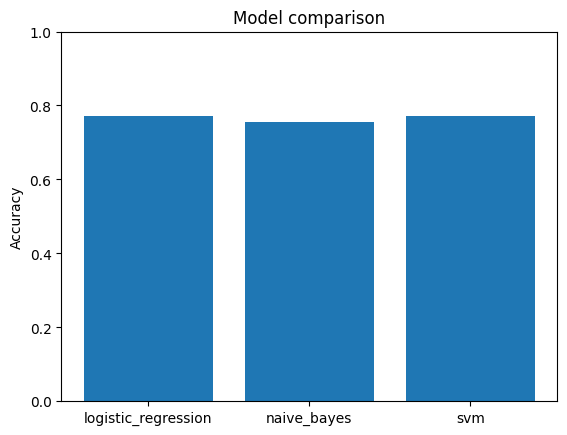

{'logistic_regression': 0.771065625,
 'naive_bayes': 0.754409375,
 'svm': 0.770653125}

In [6]:
import matplotlib.pyplot as plt

accuracies = {name: r["results"]["accuracy"] for name, r in results_by_model.items()}

plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel("Accuracy")
plt.title("Model comparison")
plt.ylim(0, 1)
plt.show()

accuracies

## 7. Saving the best model + vectorizer

In [9]:
best_model_name = max(accuracies, key=accuracies.get)
best_model = results_by_model[best_model_name]["model"]

print(f"Best model: {best_model_name} (accuracy={accuracies[best_model_name]:.4f})")

os.makedirs("models", exist_ok=True)

save_model(best_model, "models/sentiment_model.pkl")
save_vectorizer(vectorizer, "models/vectorizer.pkl")

print("Saved to models/sentiment_model.pkl and models/vectorizer.pkl")

from google.colab import files

# Download the model files
files.download("models/sentiment_model.pkl")
files.download("models/vectorizer.pkl")

Best model: logistic_regression (accuracy=0.7711)
Saved to models/sentiment_model.pkl and models/vectorizer.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>